# Exploratory Data Analysis

O objetivo desta etapa é compreender as características da população de desenvolvimento, avaliar a qualidade dos dados e identificar padrões relevantes associados ao evento de inadimplência.

A análise servirá de base para as decisões de tratamento de dados e engenharia de variáveis realizadas nas próximas etapas.

## 1. Imports e Configurações

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd

from src.eda import *

## 2. Carregamento das Bases

In [2]:
train_base = pd.read_parquet(
    "../data/processed/train_base.parquet"
)

oot_base = pd.read_parquet(
    "../data/processed/oot_base.parquet"
)

print(train_base.shape)
print(oot_base.shape)

(61912, 34)
(19970, 34)


## 3. Visão Geral da Base

In [3]:
dataset_overview(train_base)

,dtype,missing,% missing,unique
ocupacao,str,20338,32.85,18
valor_bem_submissao,float64,1643,2.65,19278
data_solicitacao,datetime64[us],0,0.00,1461
id_cliente,int64,0,0.00,30506
tipo_contrato_submissao,str,0,0.00,3
dia_semana_solicitacao_submissao,str,0,0.00,7
valor_credito_submissao,float64,0,0.00,25800
valor_parcela_submissao,float64,1,0.00,43453
sexo,str,0,0.00,2
hora_solicitacao_submissao,int64,0,0.00,24


## 4. Análise do Target

In [4]:
target_distribution(train_base)

,total,good,bad,% bad
0,61912,61403,509,0.82


In [5]:
target_by_safra(train_base)

,safra,total,bad,good,% bad
0,2020-01,630,24,606,3.81
1,2020-02,672,11,661,1.64
2,2020-03,707,19,688,2.69
3,2020-04,729,22,707,3.02
4,2020-05,739,11,728,1.49
5,2020-06,737,9,728,1.22
6,2020-07,672,8,664,1.19
7,2020-08,668,7,661,1.05
8,2020-09,773,9,764,1.16
9,2020-10,864,6,858,0.69


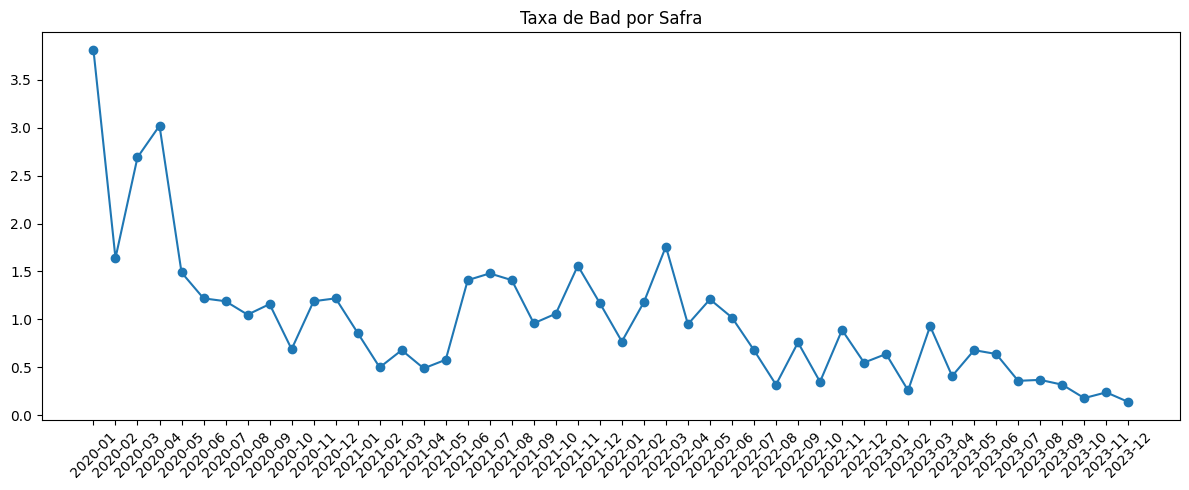

In [6]:
plot_target_by_safra(train_base)

## 5. Estabilidade Temporal do Target

In [7]:
target_by_safra(train_base)

,safra,total,bad,good,% bad
0,2020-01,630,24,606,3.81
1,2020-02,672,11,661,1.64
2,2020-03,707,19,688,2.69
3,2020-04,729,22,707,3.02
4,2020-05,739,11,728,1.49
5,2020-06,737,9,728,1.22
6,2020-07,672,8,664,1.19
7,2020-08,668,7,661,1.05
8,2020-09,773,9,764,1.16
9,2020-10,864,6,858,0.69


## 6. Qualidade dos Dados

In [8]:
missing_report(train_base)

,variable,missing,% missing
0,ocupacao,20338,32.85
1,valor_bem_submissao,1643,2.65
2,data_solicitacao,0,0.00
3,id_cliente,0,0.00
4,tipo_contrato_submissao,0,0.00
5,dia_semana_solicitacao_submissao,0,0.00
6,valor_credito_submissao,0,0.00
7,valor_parcela_submissao,1,0.00
8,sexo,0,0.00
9,hora_solicitacao_submissao,0,0.00


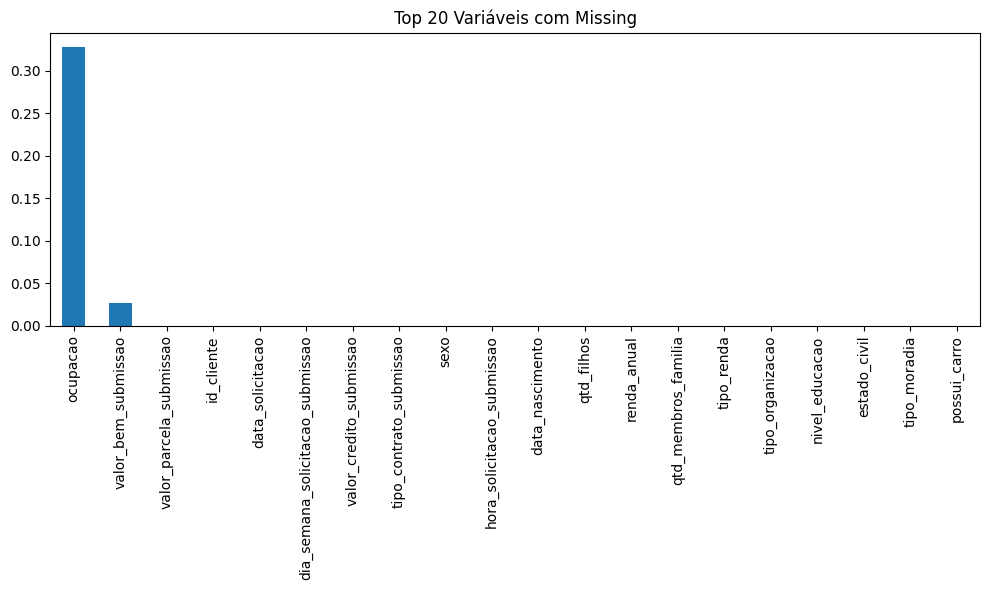

In [9]:
plot_missing(train_base)

## 7. Análise Univariada

In [10]:
numeric_summary(train_base)

,count,mean,min,25%,50%,75%,max,std
data_nascimento,61912,1980-07-29 20:46:27.802041,1956-02-16 00:00:00,1970-04-22 00:00:00,1981-06-08 00:00:00,1990-07-23 00:00:00,2004-03-10 00:00:00,NaN
data_solicitacao,61912,2022-06-16 20:13:49.874660,2020-01-01 00:00:00,2021-08-21 00:00:00,2022-09-10 12:00:00,2023-05-22 00:00:00,2023-12-31 00:00:00,NaN
hora_solicitacao_submissao,61912.0,12.59163,0.0,10.0,12.0,15.0,23.0,3.325421
id_cliente,61912.0,278582.507753,100023.0,190582.0,279049.0,366430.0,456248.0,102218.89849
max_delay,61912.0,-0.542011,-917.0,-7.0,-1.0,2.0,1560.0,27.559938
media_valor_credito_aceito_historico,61912.0,157896.920831,7222.5,62934.75,109491.0,194923.245536,3524220.0,158019.030248
nota_regiao_cliente,61912.0,2.063445,1.0,2.0,2.0,2.0,3.0,0.501983
nota_regiao_cliente_cidade,61912.0,2.037359,1.0,2.0,2.0,2.0,3.0,0.494949
qtd_contratos_aceitos_historico,61912.0,2.832569,1.0,1.0,2.0,4.0,22.0,1.972663
qtd_contratos_recusados_historico,61912.0,0.456228,0.0,0.0,0.0,0.0,31.0,1.21061


In [11]:
categorical_summary(train_base)

,variable,unique,missing
0,dia_semana_solicitacao_submissao,7,0
1,tipo_contrato_submissao,3,0
2,sexo,2,0
3,tipo_renda,7,0
4,ocupacao,18,20338
5,tipo_organizacao,58,0
6,nivel_educacao,5,0
7,estado_civil,5,0
8,tipo_moradia,6,0
9,possui_carro,2,0


## 8. Relação entre Variáveis e Inadimplência

In [12]:
target_rate_by_category(
    train_base,
    "tipo_renda"
)

,tipo_renda,total,bad_rate
5,Unemployed,5,20.00
2,Pensioner,12240,0.99
6,Working,31306,0.82
0,Commercial associate,14148,0.74
3,State servant,4207,0.64
1,Maternity leave,4,0.00
4,Student,2,0.00


In [13]:
target_rate_by_category(
    train_base,
    "estado_civil"
)

,estado_civil,total,bad_rate
4,Widow,3504,1.11
0,Civil marriage,6073,1.00
3,Single / not married,8037,0.96
1,Married,40349,0.76
2,Separated,3949,0.61


In [14]:
target_rate_by_category(
    train_base,
    "tipo_moradia"
)

,tipo_moradia,total,bad_rate
0,Co-op apartment,165,1.21
4,Rented apartment,901,1.00
5,With parents,2710,0.85
1,House / apartment,55451,0.82
3,Office apartment,442,0.68
2,Municipal apartment,2243,0.67


In [15]:
target_rate_by_category(
    train_base,
    "ocupacao"
)

,ocupacao,total,bad_rate
9,Low-skill Laborers,395,1.77
17,Waiters/barmen staff,296,1.69
12,Private service staff,551,1.09
4,Drivers,3576,1.09
14,Sales staff,6543,0.95
11,Medicine staff,1755,0.85
3,Core staff,5086,0.85
2,Cooking staff,1268,0.79
16,Security staff,1392,0.79
8,Laborers,10936,0.77


## 9. Correlação entre Variáveis Numéricas

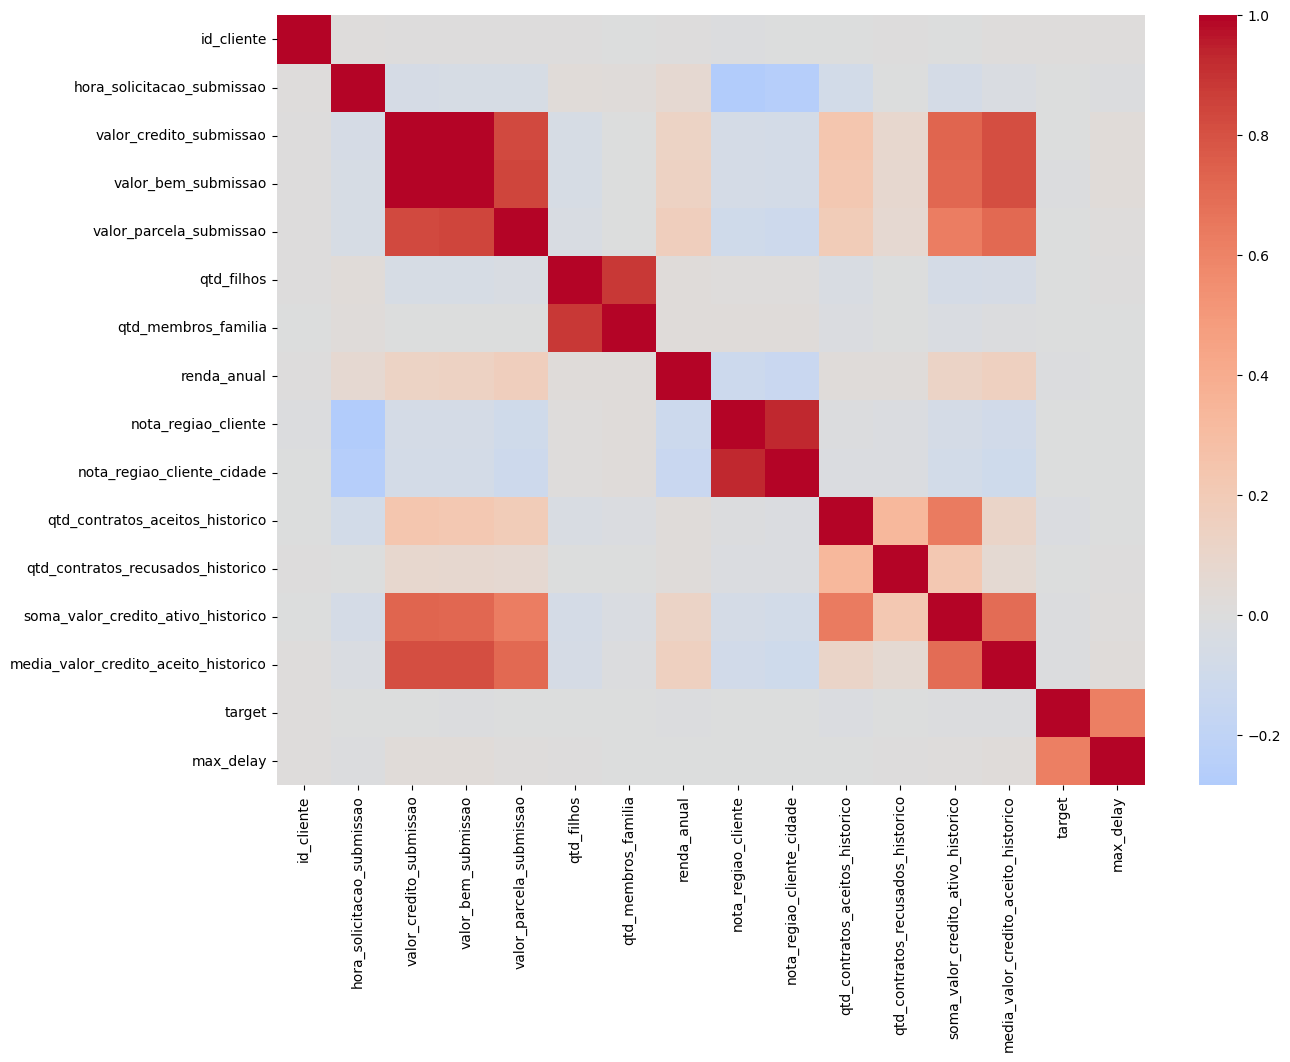

In [16]:
corr = correlation_matrix(train_base)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.show()

## 10. Principais Insights

Principais achados observados durante a análise:

- Taxa de inadimplência da população;
- Estabilidade temporal do target;
- Variáveis com maior volume de missing;
- Variáveis com maior diferenciação entre bons e maus;
- Possíveis sinais de multicolinearidade.

## 11. Conclusão

A análise exploratória permitiu validar a qualidade geral da base de desenvolvimento, compreender a distribuição do target e identificar potenciais variáveis relevantes para previsão de inadimplência.

Os resultados desta etapa serão utilizados para orientar as decisões de Feature Engineering e preparação final dos dados para modelagem.